# Figure 6: SHAP feature analysis results showing the mean shap of the absolute value of SHAP values by technology type and scenario for interconnection cost (IC) and locational marginal price (LMP). 

**NOTE:** To run this notebook, the `prepare_data.ipynb` and `run_analysis.ipynb` notebooks must first be run and all prerequisite data must be downloaded.

### Imports

In [23]:
import matplotlib.pyplot as plt
import itertools
import pandas as pd
from matplotlib.lines import Line2D
import numpy as np
import shap
import pickle
import os

### Paths

In [4]:
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
fig_dir = os.path.join(os.path.dirname(os.getcwd()), 'figures')
analysis_fn = os.path.join(data_dir, 'feature_analysis_output.csv')

### Settings

In [5]:
tech_rename_dict = {
        'gridcerf_gas_cc_no-ccs_recirculating': 'Gas CC (RE)',
        'gridcerf_gas_turbine_no-ccs_no-cooling': 'Gas CT',
        'gridcerf_solar_pv_centralized_no-cooling': 'Solar PV',
        'gridcerf_wind_onshore_hubheight100_no-cooling': 'Wind (100m)',
        'gridcerf_wind_onshore_hubheight120_no-cooling': 'Wind (120m)',
        'gridcerf_wind_onshore_hubheight140_no-cooling': 'Wind (140m)',
        'gridcerf_wind_onshore_hubheight80_no-cooling': 'Wind (80m)'}

color_map = {
    "rcp45": "#320773",  # blue
    "rcp85": "#e3942d",  # orange
}

# Assign markers
marker_map = {
    "ssp3": "o",   # circle
    "ssp5": "s"    # square
}

custom_tech_order = ['Gas CT', 'Gas CC (RE)', 'Gas CC (DR)', 'Solar PV', 'Wind (80m)', 
                     'Wind (100m)', 'Wind (120m)', 'Wind (140m)']

### Read Data

In [12]:
def read_data(analysis_fn, scenario_list, tech_rename_dict):

    # read data
    df = pd.read_csv(analysis_fn) 
    df = df[df.scenario.isin(scenario_list)]

    df['rcp'] = np.where(df.scenario.str.contains('45'), 'rcp45', 'rcp85')
    df['ssp'] = np.where(df.scenario.str.contains('ssp5'), 'ssp5', 'ssp3')                     
    df['climate'] = np.where(df.scenario.str.contains('cooler'), 'cooler', 'hotter')
    
    # rename items
    df['tech'] = df['tech'].map(tech_rename_dict)
    
    df['feature'] = df['feature'].replace('abs_lmp', 'LMP')
    df['feature'] = df['feature'].replace('abs_ic', 'IC')
    
    # Apply the custom order to the tech column
    df["tech"] = pd.Categorical(df["tech"], categories=custom_tech_order, ordered=True)
    unique_pairs = df[["tech", "feature"]].drop_duplicates()
    unique_pairs = unique_pairs.sort_values(["tech", "feature"]).reset_index(drop=True)
    unique_pairs["pos"] = range(len(unique_pairs))

    # Merge positions back into data
    df = df.merge(unique_pairs, on=["tech", "feature"], how="left")

    return df, unique_pairs

### Figure 6

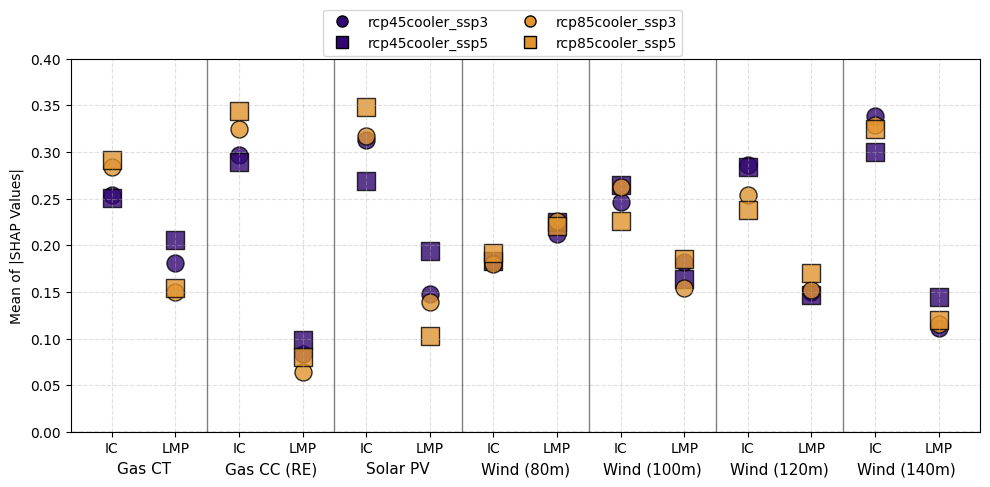

In [71]:
scenario_list = ['rcp45cooler_ssp3',
                 'rcp45cooler_ssp5',
                 'rcp85cooler_ssp3',
                 'rcp85cooler_ssp5']

df, unique_pairs = read_data(
                    analysis_fn=analysis_fn, 
                    scenario_list=scenario_list, 
                    tech_rename_dict=tech_rename_dict)


fig, ax = plt.subplots(figsize=(10, 5))

for _, row in df.iterrows():
    facecolor = color_map[row["rcp"]] if row["climate"] == "cooler" else "none"
    edgecolor = "black" if row["climate"] == "cooler" else color_map[row["rcp"]]
    ax.scatter(
        row["pos"], row["abs_shap"],
        facecolor=facecolor,
        edgecolor=edgecolor,
        marker=marker_map[row["ssp"]],
        s=150,
        linewidth=1,
        alpha=0.8,
    )

ax.set_ylabel("Mean of |SHAP Values|")
ax.set_title("")
ax.grid(True, linestyle="--", alpha=0.4)


legend_handles = []
for (color_cat, shape_cat, fill_cat) in itertools.product(color_map.keys(), marker_map.keys(), ["cooler"]):
    facecolor = color_map[color_cat] if fill_cat == "cooler" else "none"
    edgecolor = "black"
    handle = Line2D(
        [0], [0],
        marker=marker_map[shape_cat],
        color='w',
        markerfacecolor=facecolor,
        markeredgecolor=edgecolor,
        markersize=8,
        linewidth=0,
        label=f"{color_cat}cooler_{shape_cat}"
    )
    legend_handles.append(handle)
ax.legend(handles=legend_handles, title="", bbox_to_anchor=(.27, 1.15), loc="upper left", ncol=2)


ax.set_xticks(unique_pairs["pos"])
ax.set_xticklabels(unique_pairs["feature"], fontsize=10)
ax.set_ylim(0, .4)
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

main_cat_positions = unique_pairs.groupby("tech", observed=False)["pos"].mean()
for cat, xpos in main_cat_positions.items():
    ax.text(
        xpos, -0.08, cat,
        ha="center", va="top",
        fontsize=11, 
        rotation=0,
        transform=ax.get_xaxis_transform()
    )

boundaries = []
for main_cat in unique_pairs["tech"].unique():
    sub_pos = unique_pairs[unique_pairs["tech"] == main_cat]["pos"].values
    max_pos = sub_pos.max()
    boundaries.append(max_pos + 0.5)

for b in boundaries[:-1]: 
    ax.axvline(b, color="black", linestyle="-", linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'fig6.png'), dpi = 400, bbox_inches = 'tight')
plt.show()


### Supplemental Figure 5

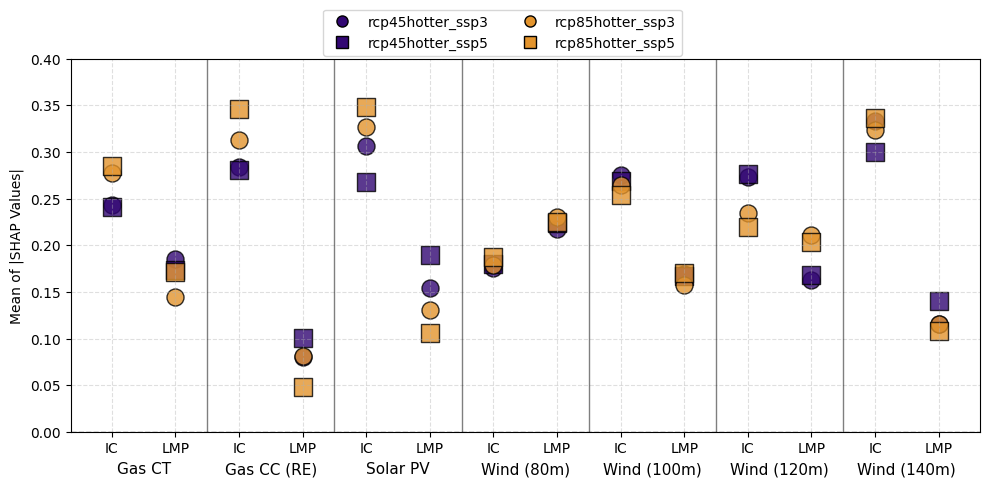

In [72]:
scenario_list = ['rcp45hotter_ssp3',
                 'rcp45hotter_ssp5',
                 'rcp85hotter_ssp3',
                 'rcp85hotter_ssp5']

df, unique_pairs = read_data(
                    analysis_fn=analysis_fn, 
                    scenario_list=scenario_list, 
                    tech_rename_dict=tech_rename_dict)

fig, ax = plt.subplots(figsize=(10, 5))

for _, row in df.iterrows():
    facecolor = color_map[row["rcp"]] if row["climate"] == "hotter" else "none"
    edgecolor = "black" if row["climate"] == "hotter" else color_map[row["rcp"]]
    ax.scatter(
        row["pos"], row["abs_shap"],
        facecolor=facecolor,
        edgecolor=edgecolor,
        marker=marker_map[row["ssp"]],
        s=150,
        linewidth=1,
        alpha=0.8,
    )

ax.set_ylabel("Mean of |SHAP Values|")
ax.set_title("")
ax.grid(True, linestyle="--", alpha=0.4)


legend_handles = []
for (color_cat, shape_cat, fill_cat) in itertools.product(color_map.keys(), marker_map.keys(), ["hotter"]):
    facecolor = color_map[color_cat] if fill_cat == "hotter" else "none"
    edgecolor = "black"
    handle = Line2D(
        [0], [0],
        marker=marker_map[shape_cat],
        color='w',
        markerfacecolor=facecolor,
        markeredgecolor=edgecolor,
        markersize=8,
        linewidth=0,
        label=f"{color_cat}hotter_{shape_cat}"
    )
    legend_handles.append(handle)
ax.legend(handles=legend_handles, title="", bbox_to_anchor=(.27, 1.15), loc="upper left", ncol=2)

ax.set_xticks(unique_pairs["pos"])
ax.set_xticklabels(unique_pairs["feature"], fontsize=10)
ax.set_ylim(0, .4)
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

main_cat_positions = unique_pairs.groupby("tech", observed=False)["pos"].mean()
for cat, xpos in main_cat_positions.items():
    ax.text(
        xpos, -0.08, cat,
        ha="center", va="top",
        fontsize=11, 
        rotation=0,
        transform=ax.get_xaxis_transform()
    )

boundaries = []
for main_cat in unique_pairs["tech"].unique():
    sub_pos = unique_pairs[unique_pairs["tech"] == main_cat]["pos"].values
    max_pos = sub_pos.max()
    boundaries.append(max_pos + 0.5)

for b in boundaries[:-1]: 
    ax.axvline(b, color="black", linestyle="-", linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'si_5.png'), dpi = 400, bbox_inches = 'tight')
plt.show()


### Supplemental Figures 6-11

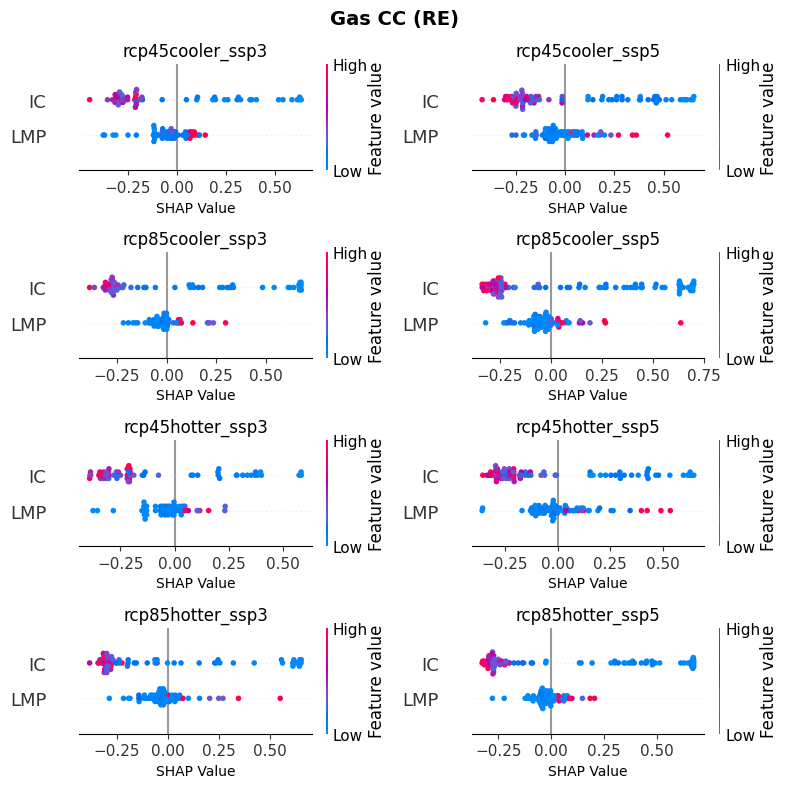

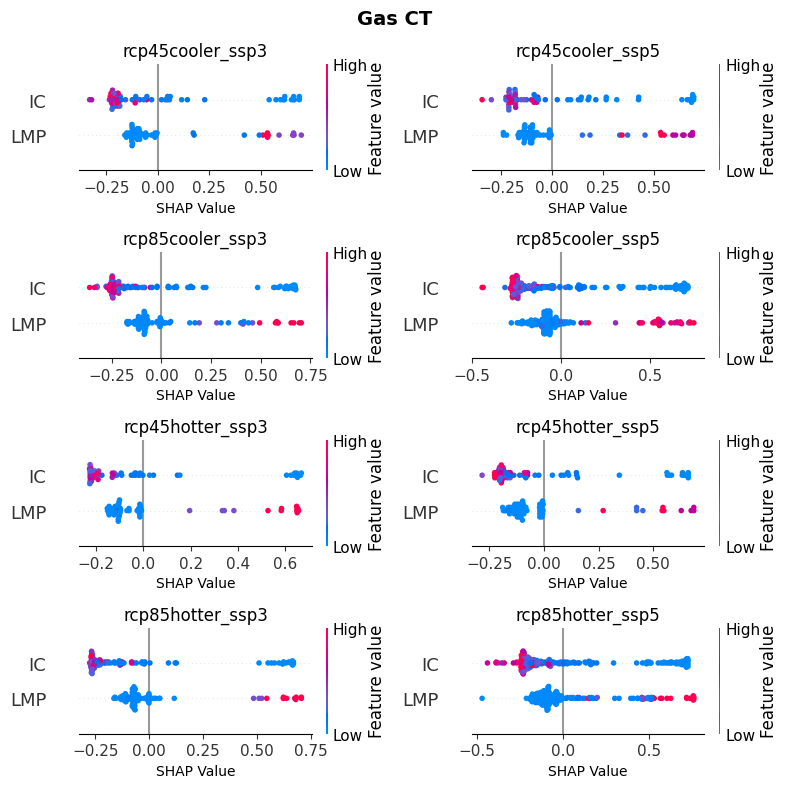

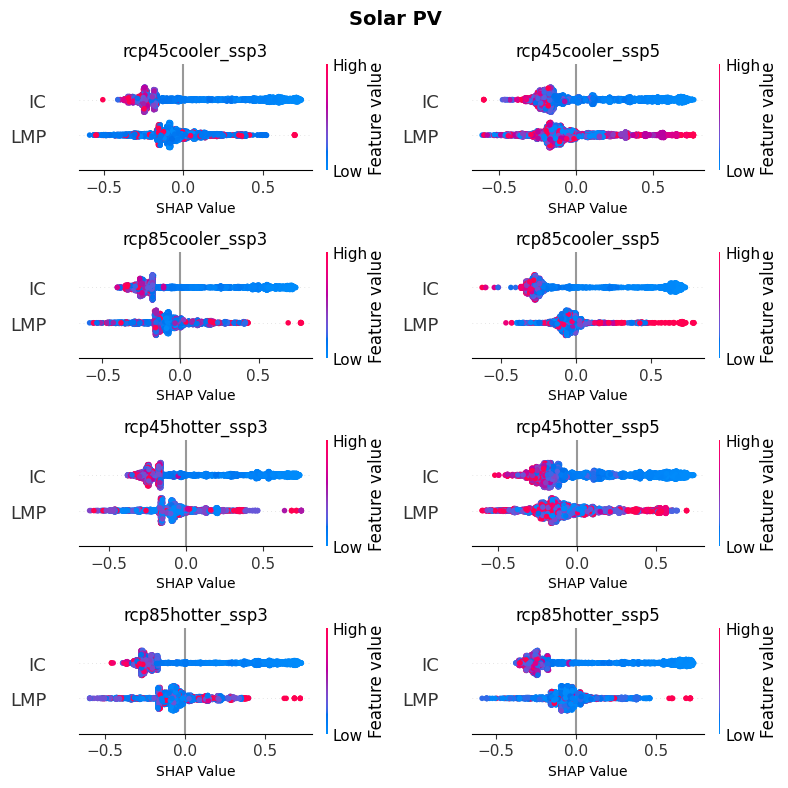

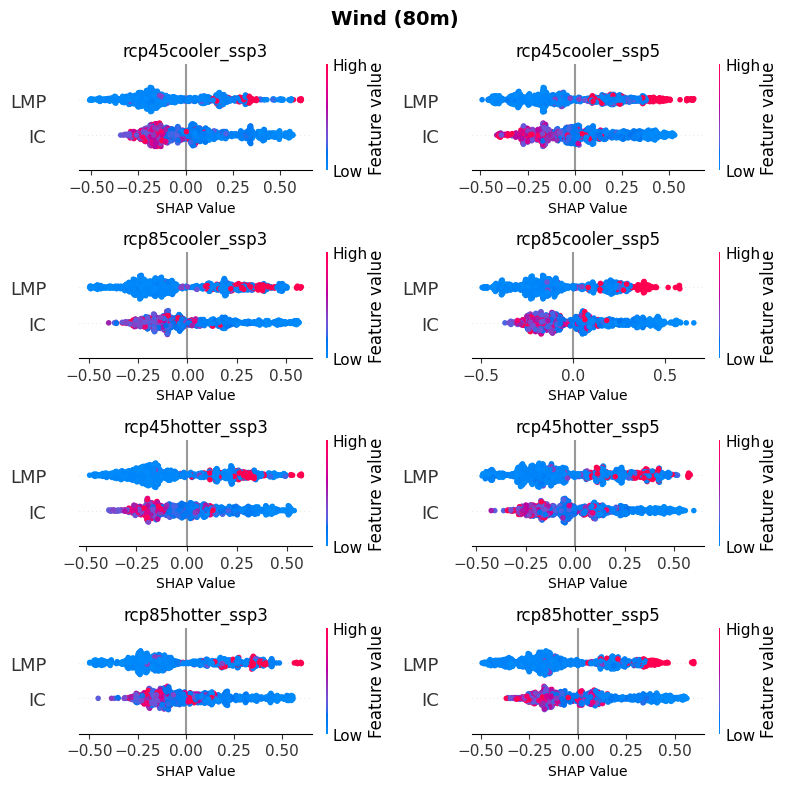

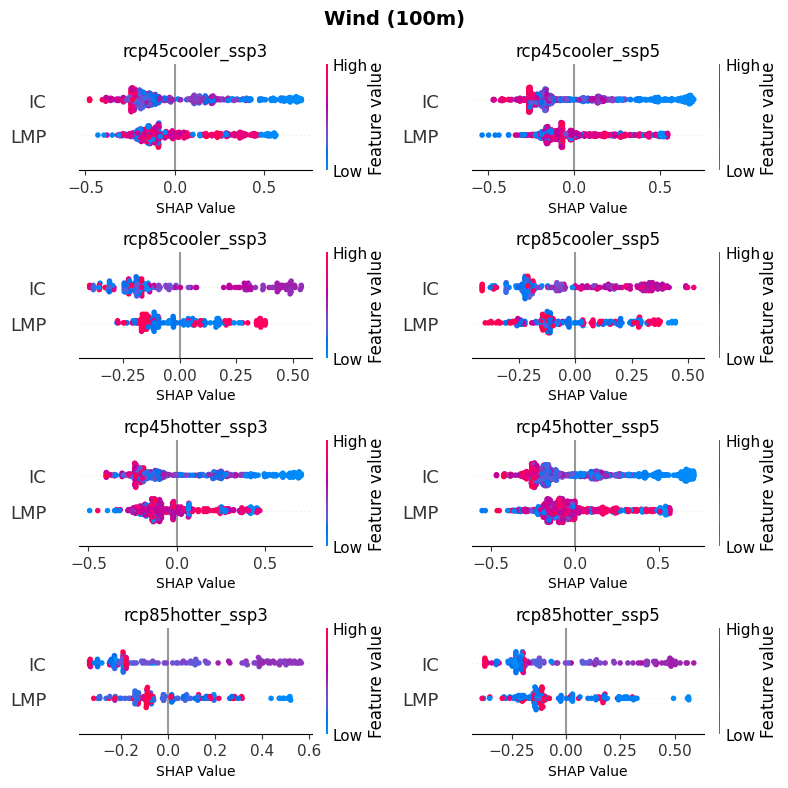

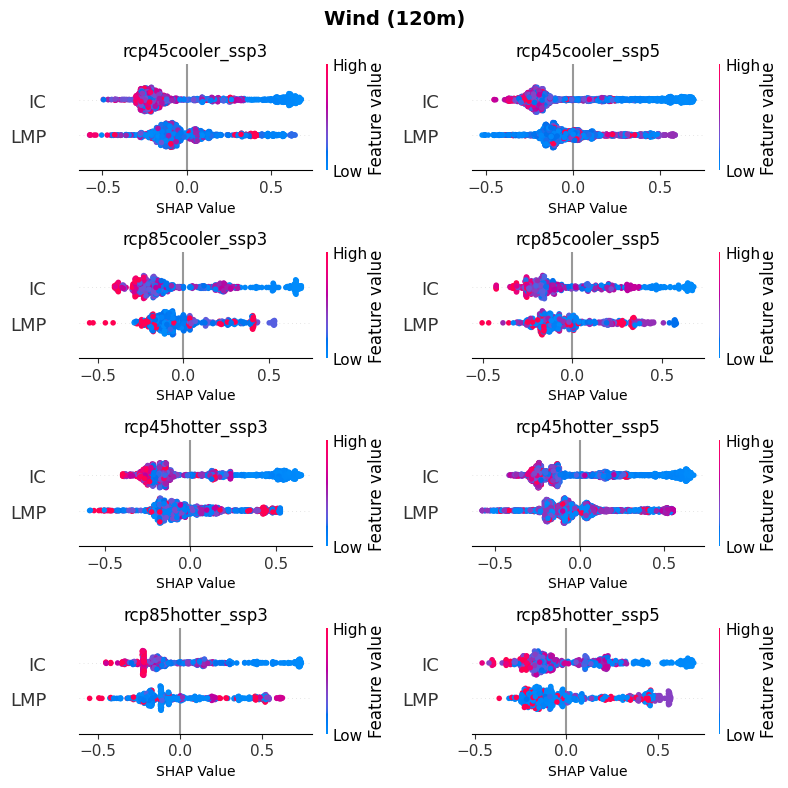

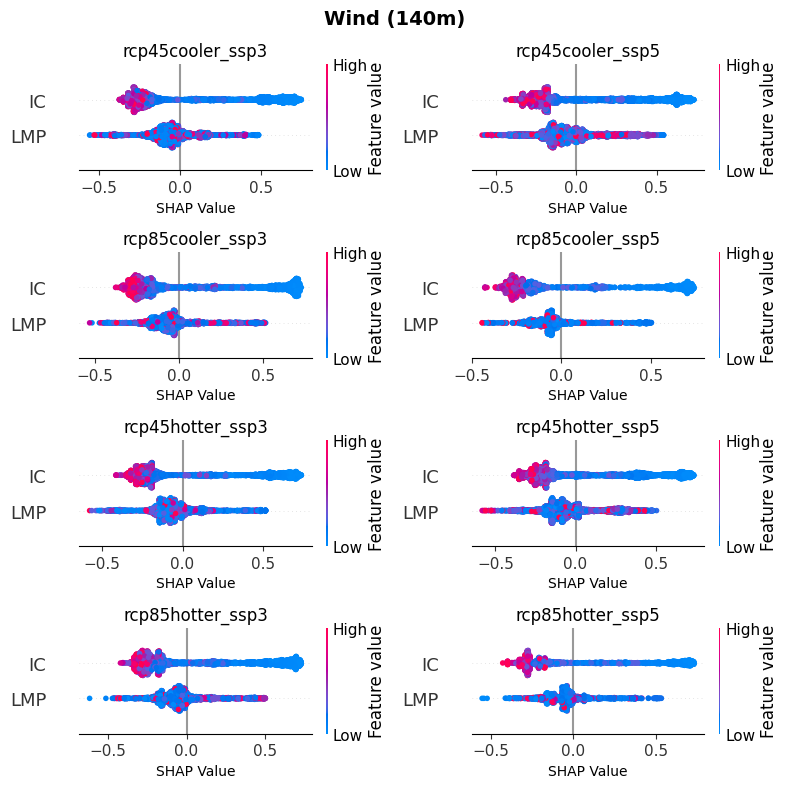

In [70]:
scenario_list = ['rcp45cooler_ssp3',
                 'rcp45cooler_ssp5',
                 'rcp85cooler_ssp3',
                 'rcp85cooler_ssp5',
                 'rcp45hotter_ssp3',
                 'rcp45hotter_ssp5',
                 'rcp85hotter_ssp3',
                 'rcp85hotter_ssp5'
                ]
tech_list =[
    'gridcerf_gas_cc_no-ccs_recirculating',
    'gridcerf_gas_turbine_no-ccs_no-cooling',
    'gridcerf_solar_pv_centralized_no-cooling',
    'gridcerf_wind_onshore_hubheight80_no-cooling',
    'gridcerf_wind_onshore_hubheight100_no-cooling',
    'gridcerf_wind_onshore_hubheight120_no-cooling',
    'gridcerf_wind_onshore_hubheight140_no-cooling',

    ]
j = 6
for n, tech in enumerate(tech_list):
    shap_runs = []
    for scenario in scenario_list:
        
        # Load the saved shap_values pickle object
        with open(os.path.join(data_dir, 'shap_values', f'{tech}_{scenario}_shap_values.pkl'), 'rb') as f:
            loaded_shap_values = pickle.load(f)
            
            # Select SHAP values for the positive (sited = 1) class
            class_idx = 1 
            single_output = loaded_shap_values[:, :, class_idx]

                        # Wrap in Explanation object
            wrapped = shap.Explanation(
                values=single_output,
                base_values=np.zeros(single_output.shape[0]),  # one base value per sample
                feature_names=["Feature 0", "Feature 1"]
            )
            
            shap_runs.append(wrapped)

    
    ncols = 2
    nrows =  4
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 8))
    axes = np.ravel(axes)  # safe flattening


    labels = scenario_list
    for i, (sv, label) in enumerate(zip(shap_runs, labels)):
        sv.feature_names = ['IC', 'LMP']
        ax = axes[i]

        shap.plots.beeswarm(
            sv,
            max_display=2,
            show=False,
            ax=ax,
            plot_size=None   # prevent SHAP from trying to resize
        )
        ax.set_title(label, fontsize=12)
        ax.set_xlabel("SHAP Value", fontsize=10)  # change font size
    
    fig.suptitle(f"{tech_rename_dict[tech]}", fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f'si_{j}.png'), dpi = 400, bbox_inches = 'tight')
    j +=1
    plt.show()
    